# Homework: Linear Equations

I will implement a small C++ linear algebra library with:

- `pp::vector`
- `pp::matrix`
- `pp::qr`

The QR decomposition is done using modified Gram-Schmidt orthogonalization.

And test:

- $Q^TQ = I$
- $QR = A$
- solving $Ax=b$
- determinant from $R$
- inverse matrix

In [1]:
import subprocess, os
from pathlib import Path

for cmd in [["python3", "--version"], ["g++", "--version"], ["make", "--version"]]:
    print("$", " ".join(cmd))
    r = subprocess.run(cmd, text=True, capture_output=True)
    print(r.stdout if r.returncode == 0 else r.stderr)

$ python3 --version
Python 3.12.3

$ g++ --version
g++ (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
Copyright (C) 2023 Free Software Foundation, Inc.
This is free software; see the source for copying conditions.  There is NO
warranty; not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.


$ make --version
GNU Make 4.3
Built for x86_64-pc-linux-gnu
Copyright (C) 1988-2020 Free Software Foundation, Inc.
License GPLv3+: GNU GPL version 3 or later <http://gnu.org/licenses/gpl.html>
This is free software: you are free to change and redistribute it.
There is NO WARRANTY, to the extent permitted by law.



So the structure will be:
- H_Linear_Equations.ipynb   = Python notebook / runner
- matrix.hpp                 = C++ implementation
- main.cpp                   = C++ test program

and they are compiled with:
- g++ -std=c++23 main.cpp -o main

# Task A-B

## matrix.hpp

In [ ]:
Path("matrix.hpp").write_text(r'''
#pragma once
#include <vector>
#include <cmath>
#include <cassert>
#include <stdexcept>
#include <iostream>
#include <iomanip>
#include <string>
#include <algorithm>

namespace pp {

class vector {
private:
    std::vector<double> data;

public:
    vector() = default;
    explicit vector(int n) : data(n, 0.0) {}
    vector(std::initializer_list<double> list) : data(list) {}

    int size() const { return static_cast<int>(data.size()); }

    double& operator[](int i) { return data[i]; }
    const double& operator[](int i) const { return data[i]; }

    vector& operator+=(const vector& other) {
        assert(size() == other.size());
        for (int i = 0; i < size(); ++i) data[i] += other[i]; return *this;
    }

    vector& operator-=(const vector& other) {
        assert(size() == other.size());
        for (int i = 0; i < size(); ++i) data[i] -= other[i]; return *this;
    }

    vector& operator*=(double c) {
        for (double& x : data) x *= c; return *this;
    }

    vector& operator/=(double c) {
        if (std::abs(c) < 1e-15) throw std::runtime_error("division by zero");
        for (double& x : data) x /= c; return *this;
    }

    double dot(const vector& other) const {
        assert(size() == other.size()); double s = 0.0;
        for (int i = 0; i < size(); ++i) s += data[i] * other[i]; return s;
    }

    double norm() const {
        return std::sqrt(dot(*this));
    }
};

inline vector operator+(vector a, const vector& b) { return a += b; }
inline vector operator-(vector a, const vector& b) { return a -= b; }
inline vector operator*(vector a, double c) { return a *= c; }
inline vector operator*(double c, vector a) { return a *= c; }
inline vector operator/(vector a, double c) { return a /= c; }

class matrix {
private:
    std::vector<vector> cols;

public:
    matrix() = default;
    matrix(int n, int m) : cols(m, vector(n)) {}

    int size1() const { return cols.empty() ? 0 : cols[0].size(); } // rows
    int size2() const { return static_cast<int>(cols.size()); }     // columns

    double& operator()(int i, int j) { return cols[j][i]; }
    const double& operator()(int i, int j) const { return cols[j][i]; }

    vector& operator[](int j) { return cols[j]; }
    const vector& operator[](int j) const { return cols[j]; }

    static matrix identity(int n) {
        matrix I(n, n);
        for (int i = 0; i < n; ++i) I(i, i) = 1.0;
        return I;
    }

    matrix T() const {
        matrix B(size2(), size1());
        for (int i = 0; i < size1(); ++i)
            for (int j = 0; j < size2(); ++j)
                B(j, i) = (*this)(i, j);
        return B;
    }
};

inline vector operator*(const matrix& A, const vector& x) {
    assert(A.size2() == x.size());
    vector b(A.size1());

    for (int j = 0; j < A.size2(); ++j)
        for (int i = 0; i < A.size1(); ++i)
            b[i] += A(i, j) * x[j];

    return b;
}

inline matrix operator*(const matrix& A, const matrix& B) {
    assert(A.size2() == B.size1());
    matrix C(A.size1(), B.size2());

    for (int j = 0; j < B.size2(); ++j)
        C[j] = A * B[j];

    return C;
}

inline double max_abs_diff(const vector& a, const vector& b) {
    assert(a.size() == b.size());
    double err = 0.0;

    for (int i = 0; i < a.size(); ++i)
        err = std::max(err, std::abs(a[i] - b[i]));

    return err;
}

inline double max_abs_diff(const matrix& A, const matrix& B) {
    assert(A.size1() == B.size1());
    assert(A.size2() == B.size2());

    double err = 0.0;

    for (int i = 0; i < A.size1(); ++i)
        for (int j = 0; j < A.size2(); ++j)
            err = std::max(err, std::abs(A(i, j) - B(i, j)));

    return err;
}

inline bool approx(const vector& a, const vector& b, double tol = 1e-8) {
    return max_abs_diff(a, b) < tol;
}

inline bool approx(const matrix& A, const matrix& B, double tol = 1e-8) {
    return max_abs_diff(A, B) < tol;
}

inline bool is_upper_triangular(const matrix& A, double tol = 1e-10) {
    for (int i = 0; i < A.size1(); ++i)
        for (int j = 0; j < i && j < A.size2(); ++j)
            if (std::abs(A(i, j)) > tol) return false;

    return true;
}

class qr {
public:
    matrix Q;
    matrix R;

    explicit qr(const matrix& A) : Q(A), R(A.size2(), A.size2()) {
        int m = A.size2();

        for (int i = 0; i < m; ++i) {
            R(i, i) = Q[i].norm();

            if (std::abs(R(i, i)) < 1e-14)
                throw std::runtime_error("QR failed: dependent columns");

            Q[i] /= R(i, i);

            for (int j = i + 1; j < m; ++j) {
                R(i, j) = Q[i].dot(Q[j]);
                Q[j] -= Q[i] * R(i, j);
            }
        }
    }

    vector solve(const vector& b) const {
        vector x = Q.T() * b;
        backsub(x);
        return x;
    }

    double det() const {
        double d = 1.0;

        for (int i = 0; i < R.size1(); ++i)
            d *= R(i, i);

        return d;
    }

    matrix inverse() const {
        int n = R.size1();
        matrix B(n, n);

        for (int i = 0; i < n; ++i) {
            vector e(n);
            e[i] = 1.0;
            B[i] = solve(e);
        }

        return B;
    }

private:
    void backsub(vector& x) const {
        int n = R.size1();

        for (int i = n - 1; i >= 0; --i) {
            double s = 0.0;

            for (int k = i + 1; k < n; ++k)
                s += R(i, k) * x[k];

            x[i] = (x[i] - s) / R(i, i);
        }
    }
};

}
''')

print("Wrote matrix.hpp")

Wrote matrix.hpp


## main.cpp

In [3]:
Path("main.cpp").write_text(r'''
#include "matrix.hpp"
#include <iostream>
#include <random>
#include <iomanip>

pp::matrix random_matrix(int n, int m, std::mt19937& gen) {
    std::uniform_real_distribution<double> dist(-2.0, 2.0);
    pp::matrix A(n, m);

    for (int i = 0; i < n; ++i)
        for (int j = 0; j < m; ++j)
            A(i, j) = dist(gen);

    return A;
}

pp::vector random_vector(int n, std::mt19937& gen) {
    std::uniform_real_distribution<double> dist(-2.0, 2.0);
    pp::vector v(n);

    for (int i = 0; i < n; ++i)
        v[i] = dist(gen);

    return v;
}

void print_check(const std::string& name, bool ok, double err) {
    std::cout << std::left << std::setw(24) << name
              << " : " << (ok ? "OK" : "FAILED")
              << "    error = " << err << "\n";
}

int main() {
    std::mt19937 gen(1);

    std::cout << "Part A2: QR decomposition test for tall matrix\n";
    std::cout << "------------------------------------------------\n";

    int n = 7;
    int m = 4;

    pp::matrix A = random_matrix(n, m, gen);
    pp::qr decomp(A);

    pp::matrix QtQ = decomp.Q.T() * decomp.Q;
    pp::matrix QR  = decomp.Q * decomp.R;
    pp::matrix I_m = pp::matrix::identity(m);

    print_check("R upper triangular", pp::is_upper_triangular(decomp.R), 0.0);
    print_check("Q^T Q = I", pp::approx(QtQ, I_m), pp::max_abs_diff(QtQ, I_m));
    print_check("Q R = A", pp::approx(QR, A), pp::max_abs_diff(QR, A));

    std::cout << "\nPart A3: solve Ax=b for square matrix\n";
    std::cout << "------------------------------------------------\n";

    int N = 5;

    pp::matrix S = random_matrix(N, N, gen);
    pp::vector b = random_vector(N, gen);

    pp::qr sqr(S);
    pp::vector x = sqr.solve(b);
    pp::vector Ax = S * x;

    print_check("A x = b", pp::approx(Ax, b), pp::max_abs_diff(Ax, b));

    std::cout << "\nPart A4: determinant\n";
    std::cout << "------------------------------------------------\n";
    std::cout << "det(R) = " << sqr.det() << "\n";

    std::cout << "\nPart B: inverse matrix\n";
    std::cout << "------------------------------------------------\n";

    pp::matrix Sinv = sqr.inverse();
    pp::matrix ASinv = S * Sinv;
    pp::matrix I_N = pp::matrix::identity(N);

    print_check("A A^-1 = I", pp::approx(ASinv, I_N), pp::max_abs_diff(ASinv, I_N));

    return 0;
}
''')

print("Wrote main.cpp")

Wrote main.cpp


## Clean up
Cleans up matrix.hpp with { ... } so that -Wmisleading-indentation doesn't give warnings.

In [5]:
Path("matrix.hpp").write_text(r'''
#pragma once
#include <vector>
#include <cmath>
#include <cassert>
#include <stdexcept>
#include <iostream>
#include <iomanip>
#include <string>
#include <algorithm>

namespace pp {

class vector {
private:
    std::vector<double> data;

public:
    vector() = default;
    explicit vector(int n) : data(n, 0.0) {}
    vector(std::initializer_list<double> list) : data(list) {}

    int size() const {
        return static_cast<int>(data.size());
    }

    double& operator[](int i) {
        return data[i];
    }

    const double& operator[](int i) const {
        return data[i];
    }

    vector& operator+=(const vector& other) {
        assert(size() == other.size());

        for (int i = 0; i < size(); ++i) {
            data[i] += other[i];
        }

        return *this;
    }

    vector& operator-=(const vector& other) {
        assert(size() == other.size());

        for (int i = 0; i < size(); ++i) {
            data[i] -= other[i];
        }

        return *this;
    }

    vector& operator*=(double c) {
        for (double& x : data) {
            x *= c;
        }

        return *this;
    }

    vector& operator/=(double c) {
        if (std::abs(c) < 1e-15) {
            throw std::runtime_error("division by zero");
        }

        for (double& x : data) {
            x /= c;
        }

        return *this;
    }

    double dot(const vector& other) const {
        assert(size() == other.size());

        double s = 0.0;

        for (int i = 0; i < size(); ++i) {
            s += data[i] * other[i];
        }

        return s;
    }

    double norm() const {
        return std::sqrt(dot(*this));
    }
};

inline vector operator+(vector a, const vector& b) {
    return a += b;
}

inline vector operator-(vector a, const vector& b) {
    return a -= b;
}

inline vector operator*(vector a, double c) {
    return a *= c;
}

inline vector operator*(double c, vector a) {
    return a *= c;
}

inline vector operator/(vector a, double c) {
    return a /= c;
}

class matrix {
private:
    std::vector<vector> cols;

public:
    matrix() = default;
    matrix(int n, int m) : cols(m, vector(n)) {}

    int size1() const {
        return cols.empty() ? 0 : cols[0].size(); // rows
    }

    int size2() const {
        return static_cast<int>(cols.size()); // columns
    }

    double& operator()(int i, int j) {
        return cols[j][i];
    }

    const double& operator()(int i, int j) const {
        return cols[j][i];
    }

    vector& operator[](int j) {
        return cols[j];
    }

    const vector& operator[](int j) const {
        return cols[j];
    }

    static matrix identity(int n) {
        matrix I(n, n);

        for (int i = 0; i < n; ++i) {
            I(i, i) = 1.0;
        }

        return I;
    }

    matrix T() const {
        matrix B(size2(), size1());

        for (int i = 0; i < size1(); ++i) {
            for (int j = 0; j < size2(); ++j) {
                B(j, i) = (*this)(i, j);
            }
        }

        return B;
    }
};

inline vector operator*(const matrix& A, const vector& x) {
    assert(A.size2() == x.size());

    vector b(A.size1());

    for (int j = 0; j < A.size2(); ++j) {
        for (int i = 0; i < A.size1(); ++i) {
            b[i] += A(i, j) * x[j];
        }
    }

    return b;
}

inline matrix operator*(const matrix& A, const matrix& B) {
    assert(A.size2() == B.size1());

    matrix C(A.size1(), B.size2());

    for (int j = 0; j < B.size2(); ++j) {
        C[j] = A * B[j];
    }

    return C;
}

inline double max_abs_diff(const vector& a, const vector& b) {
    assert(a.size() == b.size());

    double err = 0.0;

    for (int i = 0; i < a.size(); ++i) {
        err = std::max(err, std::abs(a[i] - b[i]));
    }

    return err;
}

inline double max_abs_diff(const matrix& A, const matrix& B) {
    assert(A.size1() == B.size1());
    assert(A.size2() == B.size2());

    double err = 0.0;

    for (int i = 0; i < A.size1(); ++i) {
        for (int j = 0; j < A.size2(); ++j) {
            err = std::max(err, std::abs(A(i, j) - B(i, j)));
        }
    }

    return err;
}

inline bool approx(const vector& a, const vector& b, double tol = 1e-8) {
    return max_abs_diff(a, b) < tol;
}

inline bool approx(const matrix& A, const matrix& B, double tol = 1e-8) {
    return max_abs_diff(A, B) < tol;
}

inline bool is_upper_triangular(const matrix& A, double tol = 1e-10) {
    for (int i = 0; i < A.size1(); ++i) {
        for (int j = 0; j < i && j < A.size2(); ++j) {
            if (std::abs(A(i, j)) > tol) {
                return false;
            }
        }
    }

    return true;
}

class qr {
public:
    matrix Q;
    matrix R;

    explicit qr(const matrix& A) : Q(A), R(A.size2(), A.size2()) {
        int m = A.size2();

        for (int i = 0; i < m; ++i) {
            R(i, i) = Q[i].norm();

            if (std::abs(R(i, i)) < 1e-14) {
                throw std::runtime_error("QR failed: dependent columns");
            }

            Q[i] /= R(i, i);

            for (int j = i + 1; j < m; ++j) {
                R(i, j) = Q[i].dot(Q[j]);
                Q[j] -= Q[i] * R(i, j);
            }
        }
    }

    vector solve(const vector& b) const {
        vector x = Q.T() * b;
        backsub(x);
        return x;
    }

    double det() const {
        double d = 1.0;

        for (int i = 0; i < R.size1(); ++i) {
            d *= R(i, i);
        }

        return d;
    }

    matrix inverse() const {
        int n = R.size1();
        matrix B(n, n);

        for (int i = 0; i < n; ++i) {
            vector e(n);
            e[i] = 1.0;
            B[i] = solve(e);
        }

        return B;
    }

private:
    void backsub(vector& x) const {
        int n = R.size1();

        for (int i = n - 1; i >= 0; --i) {
            double s = 0.0;

            for (int k = i + 1; k < n; ++k) {
                s += R(i, k) * x[k];
            }

            x[i] = (x[i] - s) / R(i, i);
        }
    }
};

}
''')

print("Rewrote matrix.hpp with braces")

Rewrote matrix.hpp with braces


## Compiler

In [6]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-Wall",
    "-Wextra",
    "-O2",
    "main.cpp",
    "-o",
    "main"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    r = subprocess.run(["./main"], text=True, capture_output=True)
    print("Program output:")
    print(r.stdout)
    print(r.stderr)
else:
    print("Compilation failed.")

Compiler output:


Program output:
Part A2: QR decomposition test for tall matrix
------------------------------------------------
R upper triangular       : OK    error = 0
Q^T Q = I                : OK    error = 4.30211e-16
Q R = A                  : OK    error = 2.22045e-16

Part A3: solve Ax=b for square matrix
------------------------------------------------
A x = b                  : OK    error = 9.4369e-16

Part A4: determinant
------------------------------------------------
det(R) = 17.7168

Part B: inverse matrix
------------------------------------------------
A A^-1 = I               : OK    error = 4.44089e-16




# Task C — timing for QR-decomposition

In [7]:
Path("time.cpp").write_text(r'''
#include "matrix.hpp"
#include <iostream>
#include <random>
#include <cstdlib>

pp::matrix random_matrix(int n, int m, std::mt19937& gen) {
    std::uniform_real_distribution<double> dist(-2.0, 2.0);
    pp::matrix A(n, m);

    for (int i = 0; i < n; ++i) {
        for (int j = 0; j < m; ++j) {
            A(i, j) = dist(gen);
        }
    }

    return A;
}

int main(int argc, char** argv) {
    int N = 100;

    for (int i = 1; i < argc; ++i) {
        std::string arg = argv[i];

        if (arg == "-size" && i + 1 < argc) {
            N = std::atoi(argv[i + 1]);
            ++i;
        }
    }

    std::mt19937 gen(1);
    pp::matrix A = random_matrix(N, N, gen);

    pp::qr decomp(A);

    return 0;
}
''')

print("Wrote time.cpp")

Wrote time.cpp


In [8]:
import subprocess

compile_cmd = [
    "g++",
    "-std=c++23",
    "-O2",
    "-Wall",
    "-Wextra",
    "time.cpp",
    "-o",
    "time"
]

r = subprocess.run(compile_cmd, text=True, capture_output=True)

print("Compiler output:")
print(r.stdout)
print(r.stderr)

if r.returncode == 0:
    print("Compiled time.cpp successfully.")
else:
    print("Compilation failed.")

Compiler output:


Compiled time.cpp successfully.


In [9]:
import subprocess
from pathlib import Path

Ns = list(range(50, 401, 50))

with open("out.times.data", "w") as f:
    for N in Ns:
        cmd = f"/usr/bin/time -f '{N} %e' ./time -size {N}"
        r = subprocess.run(
            cmd,
            shell=True,
            text=True,
            capture_output=True
        )

        line = r.stderr.strip()
        print(line)
        f.write(line + "\n")

print("Wrote out.times.data")

50 0.00
100 0.00
150 0.01
200 0.01
250 0.03
300 0.04
350 0.07
400 0.11
Wrote out.times.data


In [11]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "numpy",
    "matplotlib"
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 1.2 MB/s  0:00:13m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 1.7 MB/s  0:00:05m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.5 MB/s  0:00:03 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 1.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 1.8 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [matplotlib]8 [matplotlib]


0

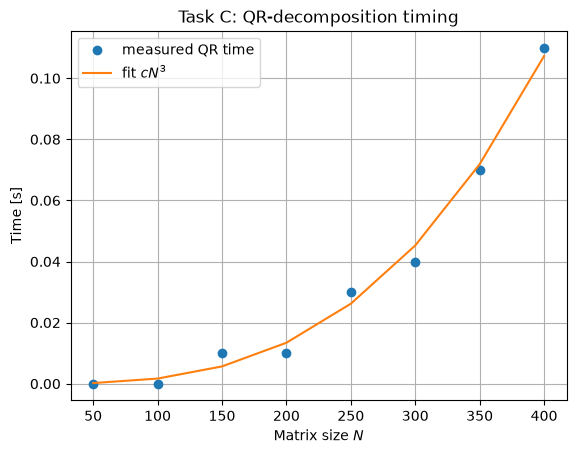

Fit constant c = 1.676e-09 s/N^3


In [12]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("out.times.data")
N = data[:, 0]
t = data[:, 1]

x = N**3
c = np.sum(x*t) / np.sum(x*x)
t_fit = c*x

plt.figure()
plt.plot(N, t, "o", label="measured QR time")
plt.plot(N, t_fit, "-", label=r"fit $cN^3$")
plt.xlabel("Matrix size $N$")
plt.ylabel("Time [s]")
plt.title("Task C: QR-decomposition timing")
plt.legend()
plt.grid(True)
plt.show()

print(f"Fit constant c = {c:.3e} s/N^3")

- Task A1: DONE — pp::vector and pp::matrix implemented
- Task A2: DONE — QR decomposition tested
- Task A3: DONE — solve(b) tested
- Task A4: DONE — det() tested
- Task B:  DONE — inverse() tested
- Task C:  DONE — timing follows approximately O(N^3)

## Task C conclusion

The measured runtime increases rapidly with the matrix size $N$ and follows the fitted curve $cN^3$ reasonably well. Which agrees with the expected operation count for modified Gram-Schmidt QR-decomposition, which scales as $O(N^3)$ for an $N \times N$ matrix.

The smallest timings are close to zero because the matrices are too small for reliable timing with `/usr/bin/time`, but the larger sizes show the expected cubic trend.